In [9]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

^C
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache direc

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

sns.set(style="whitegrid", font='NanumGothic', palette="muted")

In [11]:
netflix_df = pd.read_csv('/content/netflix_titles.csv')
disney_df = pd.read_csv('/content/disney_plus_titles.csv')

netflix_df['platform'] = 'Netflix'
disney_df['platform'] = 'Disney+'

df = pd.concat([netflix_df, disney_df], axis=0).reset_index(drop=True)

print(f"전체 데이터 개수: {df.shape[0]}개")
df.head(3)

전체 데이터 개수: 10257개


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,platform
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Netflix
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Netflix
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Netflix


In [12]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

df.dropna(subset=['date_added', 'rating'], inplace=True)

df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,3


In [13]:
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year

rating_map = {
    'TV-Y': '키즈', 'TV-Y7': '키즈', 'TV-G': '키즈', 'G': '키즈', 'TV-Y7-FV': '키즈',
    'TV-PG': '청소년', 'PG': '청소년', 'PG-13': '청소년', 'TV-14': '청소년',
    'TV-MA': '성인', 'R': '성인', 'NC-17': '성인', 'NR': '성인', 'UR': '성인'
}
df['target_age'] = df['rating'].map(rating_map)

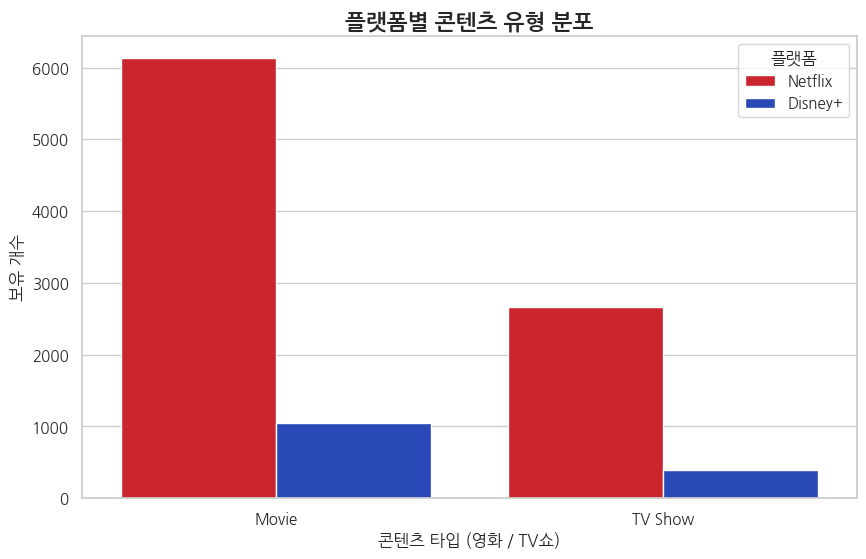

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='type', hue='platform', palette=['#E50914', '#113CCF'])

plt.title("플랫폼별 콘텐츠 유형 분포", fontsize=16, fontweight='bold')
plt.xlabel("콘텐츠 타입 (영화 / TV쇼)")
plt.ylabel("보유 개수")
plt.legend(title="플랫폼")
plt.show()

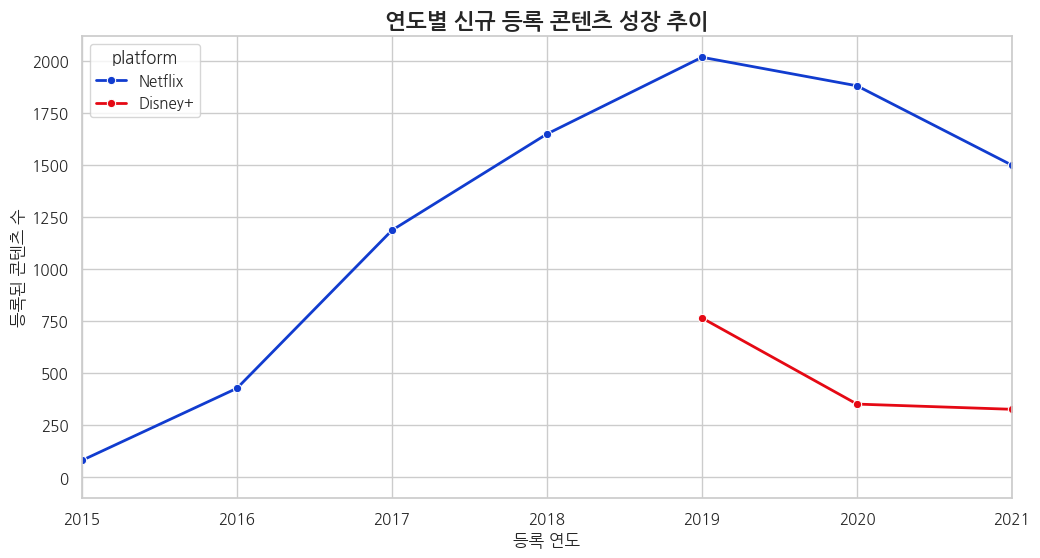

In [15]:
content_growth = df.groupby(['year_added', 'platform']).size().reset_index(name='count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=content_growth, x='year_added', y='count', hue='platform',
             palette=['#113CCF', '#E50914'], marker='o', linewidth=2)

plt.title("연도별 신규 등록 콘텐츠 성장 추이", fontsize=16, fontweight='bold')
plt.xlim(2015, 2021)
plt.xlabel("등록 연도")
plt.ylabel("등록된 콘텐츠 수")
plt.show()

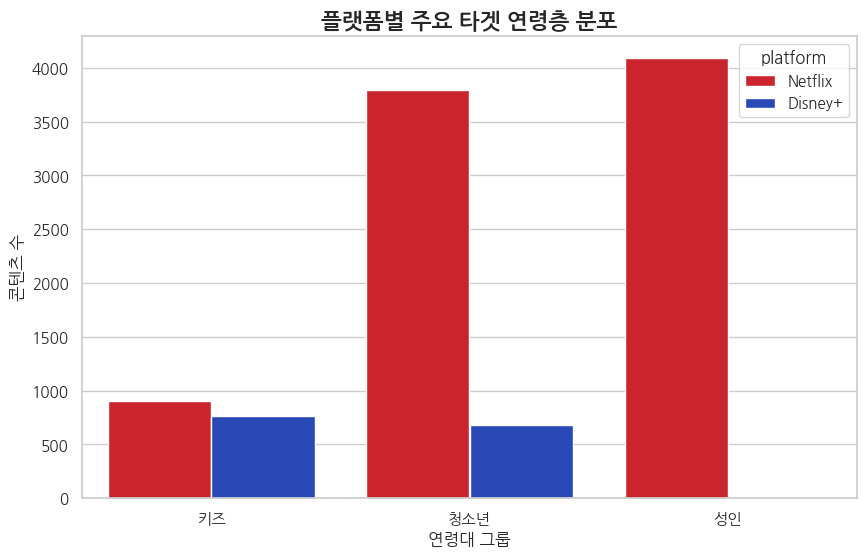

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='target_age', hue='platform',
              order=['키즈', '청소년', '성인'],
              palette=['#E50914', '#113CCF'])

plt.title("플랫폼별 주요 타겟 연령층 분포", fontsize=16, fontweight='bold')
plt.xlabel("연령대 그룹")
plt.ylabel("콘텐츠 수")
plt.show()

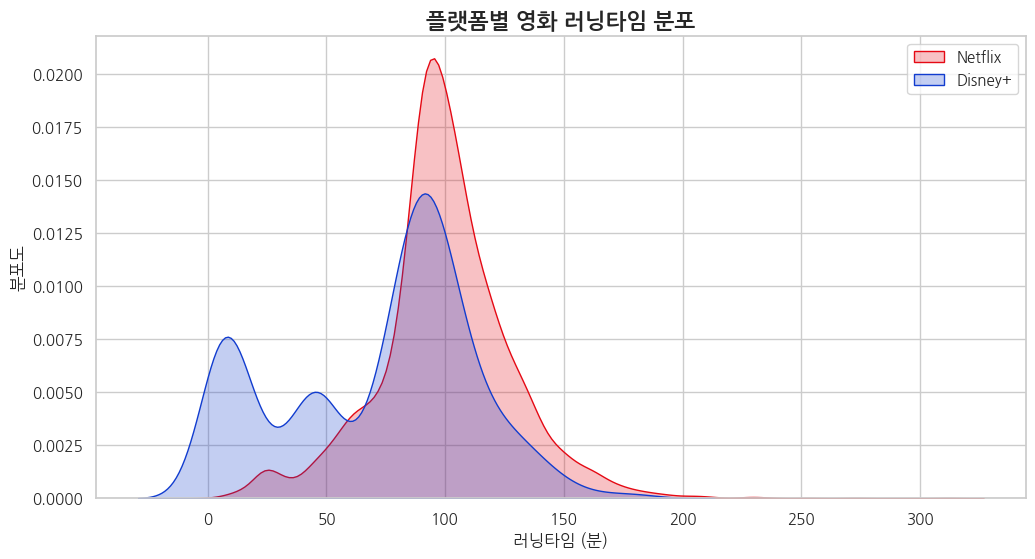

In [17]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.replace(' min', '').astype(float)

plt.figure(figsize=(12, 6))
sns.kdeplot(data=movies[movies['platform']=='Netflix'], x='duration_min', fill=True, color='#E50914', label='Netflix')
sns.kdeplot(data=movies[movies['platform']=='Disney+'], x='duration_min', fill=True, color='#113CCF', label='Disney+')

plt.title("플랫폼별 영화 러닝타임 분포", fontsize=16, fontweight='bold')
plt.xlabel("러닝타임 (분)")
plt.ylabel("분포도")
plt.legend()
plt.show()